In [212]:
import pandas as pd

# Step 1 — Problem Definition

## Objective

The goal of this project is to build a binary classification model to predict whether a breast tumor is **Malignant (M)** or **Benign (B)** using structured numeric features derived from digitized images of fine needle aspirates (FNA).

## Target Variable

- **Diagnosis**
  - M = Malignant
  - B = Benign

For modeling purposes, the target variable will be encoded as:
- 1 → Malignant
- 0 → Benign

This transforms the task into a supervised binary classification problem.

---

## Why This Problem Matters

Breast cancer diagnosis is a high-stakes medical decision problem.  
In this context:

- A **False Negative (FN)** (predicting Benign when the tumor is Malignant) can delay treatment and pose serious risk to the patient.
- A **False Positive (FP)** (predicting Malignant when it is Benign) may cause anxiety and additional testing, but is generally less dangerous than a false negative.

Therefore, evaluation metrics must go beyond simple accuracy.

---

## Evaluation Metrics Strategy

The following metrics will be used:

- **Accuracy** — Overall correctness (baseline comparison).
- **Precision** — Of predicted malignant tumors, how many are truly malignant?
- **Recall (Sensitivity)** — Of actual malignant tumors, how many are correctly detected?
- **F1-score** — Harmonic mean of precision and recall.
- **ROC-AUC** — Model’s ability to discriminate between classes across thresholds.
- **Confusion Matrix** — Detailed breakdown of classification outcomes.

### Metric Priority in Medical Context

In medical diagnosis, **Recall for the Malignant class is the most critical metric**, since minimizing false negatives is essential for patient safety.

ROC-AUC is also important because it evaluates discrimination performance independently of a specific decision threshold.

In [213]:
# Step 1 — Data Setup
import numpy as np

# Load dataset
columns = ["ID", "Diagnosis",
           "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
           "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
           "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
           "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
           "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
           "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"]




path = "Take Home Assignment #2 attached files Feb 28, 2026 322 PM/DAMO510, Winter 2026, Take-Home Assignment 2, Dataset without Header.data"

df = pd.read_csv(path, header=None, names=columns)

# Display basic structure
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Check class distribution
print("\nClass distribution:")
print(df["Diagnosis"].value_counts())

# Encode target variable
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

print("\nEncoded class distribution:")
print(df["Diagnosis"].value_counts())

Dataset shape: 569 rows, 32 columns

Class distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Encoded class distribution:
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [214]:
df = df.drop(columns=["ID"])

## Observations

- The dataset contains numeric features describing cell nucleo characteristics.
- The target variable has been successfully encoded as:
  - 1 → Malignant
  - 0 → Benign.

### Class Distribution

We inspect the class balance to determine whether imbalance handling techniques may be required later.

If the dataset shows moderate imbalance (e.g., more benign than malignant cases), this reinforces the importance of prioritizing recall and potentially using class-weighted models.

---

## Conclusion of Step 1

We have formally defined:

- The binary classification objective.
- The encoded target variable.
- A medically informed evaluation strategy prioritizing recall for malignant tumors.

We are now ready to explore the dataset structure and feature characteristics in Step 2.

# Step 2 — Exploratory Data Analysis (EDA)

## Objective of the EDA

The purpose of this exploratory analysis is to:

1. Understand the structure of the dataset.
2. Examine class balance.
3. Analyze feature distributions.
4. Detect potential scaling issues.
5. Identify multicollinearity patterns.
6. Explore relationships between features and the target variable.

A rigorous EDA is critical in medical machine learning applications, since poor preprocessing or overlooked structure may lead to misleading model performance.

In [215]:
df.head()

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [216]:
# Check data types and missing values

print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## Dataset Structure Observations

- The dataset contains only numeric predictor variables.
- No missing values are present.
- All features are continuous measurements derived from cell nuclei images.

This confirms that no imputation strategy is required.  
However, feature scaling will likely be necessary due to magnitude differences (e.g., area vs smoothness).

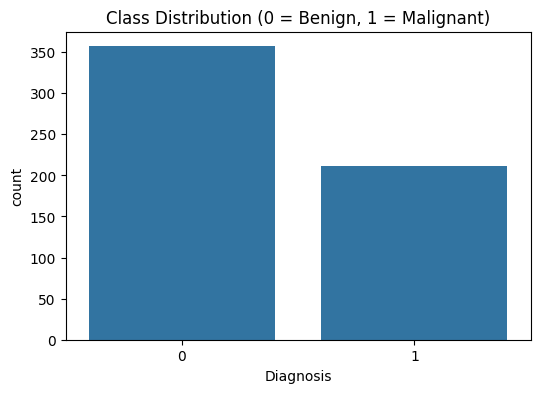

Diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


In [217]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Diagnosis", data=df)
plt.title("Class Distribution (0 = Benign, 1 = Malignant)")
plt.show()

print(df["Diagnosis"].value_counts(normalize=True))

## Class Balance Analysis

The dataset shows a moderate class imbalance, with more benign than malignant cases.

In medical diagnosis:

- Class imbalance can bias models toward predicting the majority class.
- Accuracy alone may become misleading.
- Recall for malignant tumors must be prioritized.

This reinforces the importance of using class-weighted models or other imbalance-aware strategies in later steps.

In [218]:
# Descriptive statistics

df.describe().T.sort_values("std", ascending=False).head(10)

,count,mean,std,min,25%,50%,75%,max
area_worst,569.0,880.583128,569.356993,185.200,515.300,686.500,1084.000,4254.00
area_mean,569.0,654.889104,351.914129,143.500,420.300,551.100,782.700,2501.00
area_se,569.0,40.337079,45.491006,6.802,17.850,24.530,45.190,542.20
perimeter_worst,569.0,107.261213,33.602542,50.410,84.110,97.660,125.400,251.20
perimeter_mean,569.0,91.969033,24.298981,43.790,75.170,86.240,104.100,188.50
texture_worst,569.0,25.677223,6.146258,12.020,21.080,25.410,29.720,49.54
radius_worst,569.0,16.269190,4.833242,7.930,13.010,14.970,18.790,36.04
texture_mean,569.0,19.289649,4.301036,9.710,16.170,18.840,21.800,39.28
radius_mean,569.0,14.127292,3.524049,6.981,11.700,13.370,15.780,28.11
perimeter_se,569.0,2.866059,2.021855,0.757,1.606,2.287,3.357,21.98


## Feature Scale Analysis

There is significant variation in feature magnitudes:

- Area-related features have very large numeric ranges.
- Smoothness and fractal dimensions operate on much smaller scales.

Without normalization, distance-based and linear models (e.g., Logistic Regression) would be biased toward large-scale variables.

Therefore, feature scaling will be required.

## Distribution of Predictor Variables

Understanding the distribution of each predictor is essential before modeling.

This analysis allows us to:

- Detect skewness and asymmetry.
- Identify potential outliers.
- Evaluate scale differences across variables.
- Assess whether transformations may be necessary.

Since the dataset contains geometric and texture-related measurements derived from medical imaging, non-normal distributions are expected.

The following grid of histograms displays the distribution of all numeric features.

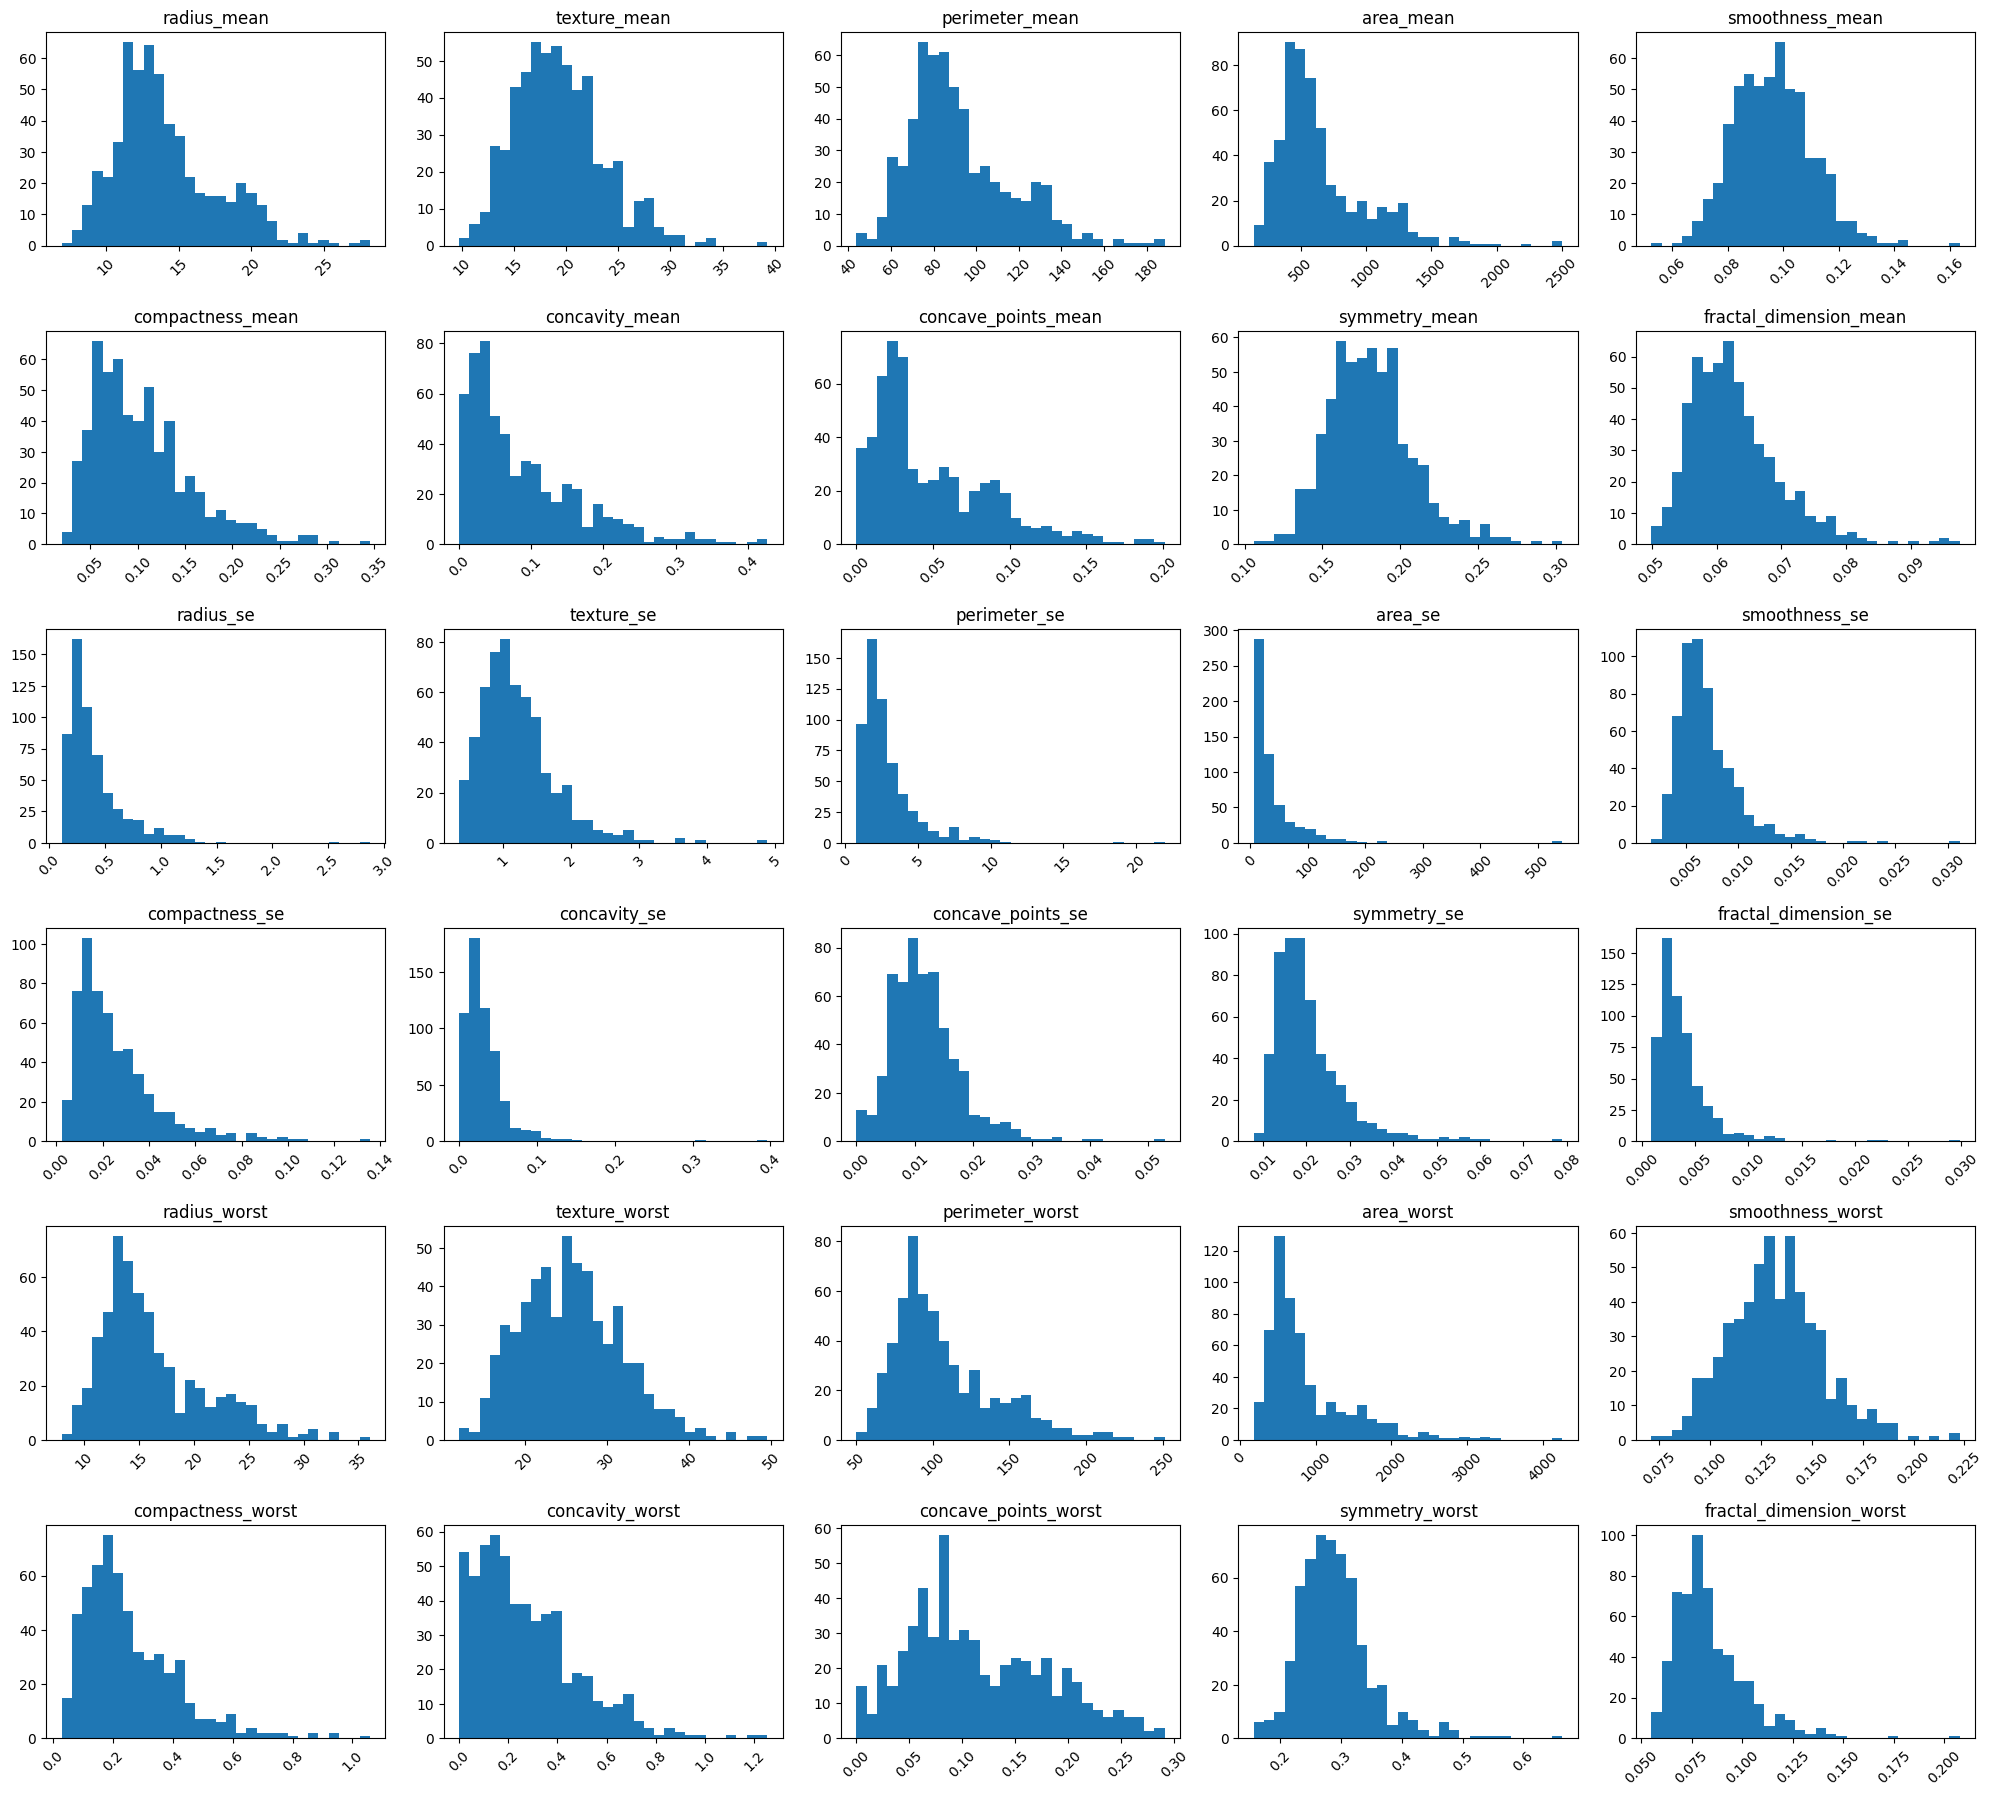

In [219]:
import matplotlib.pyplot as plt

# Drop target for pure feature distribution
features = df.drop(columns=["Diagnosis"]).columns

# Grid size
n_cols = 5
n_rows = int(np.ceil(len(features) / n_cols))

plt.figure(figsize=(20, n_rows * 3))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Feature Distributions by Diagnosis

To evaluate discriminative power, we compare feature distributions across the two diagnostic classes:

- 0 → Benign
- 1 → Malignant

Overlayed density plots allow us to:

- Visually assess separation between classes.
- Identify features with strong discriminatory potential.
- Detect overlap that may lead to classification difficulty.

Clear separation between distributions suggests strong predictive signal, 
whereas heavy overlap may indicate limited discriminative power.

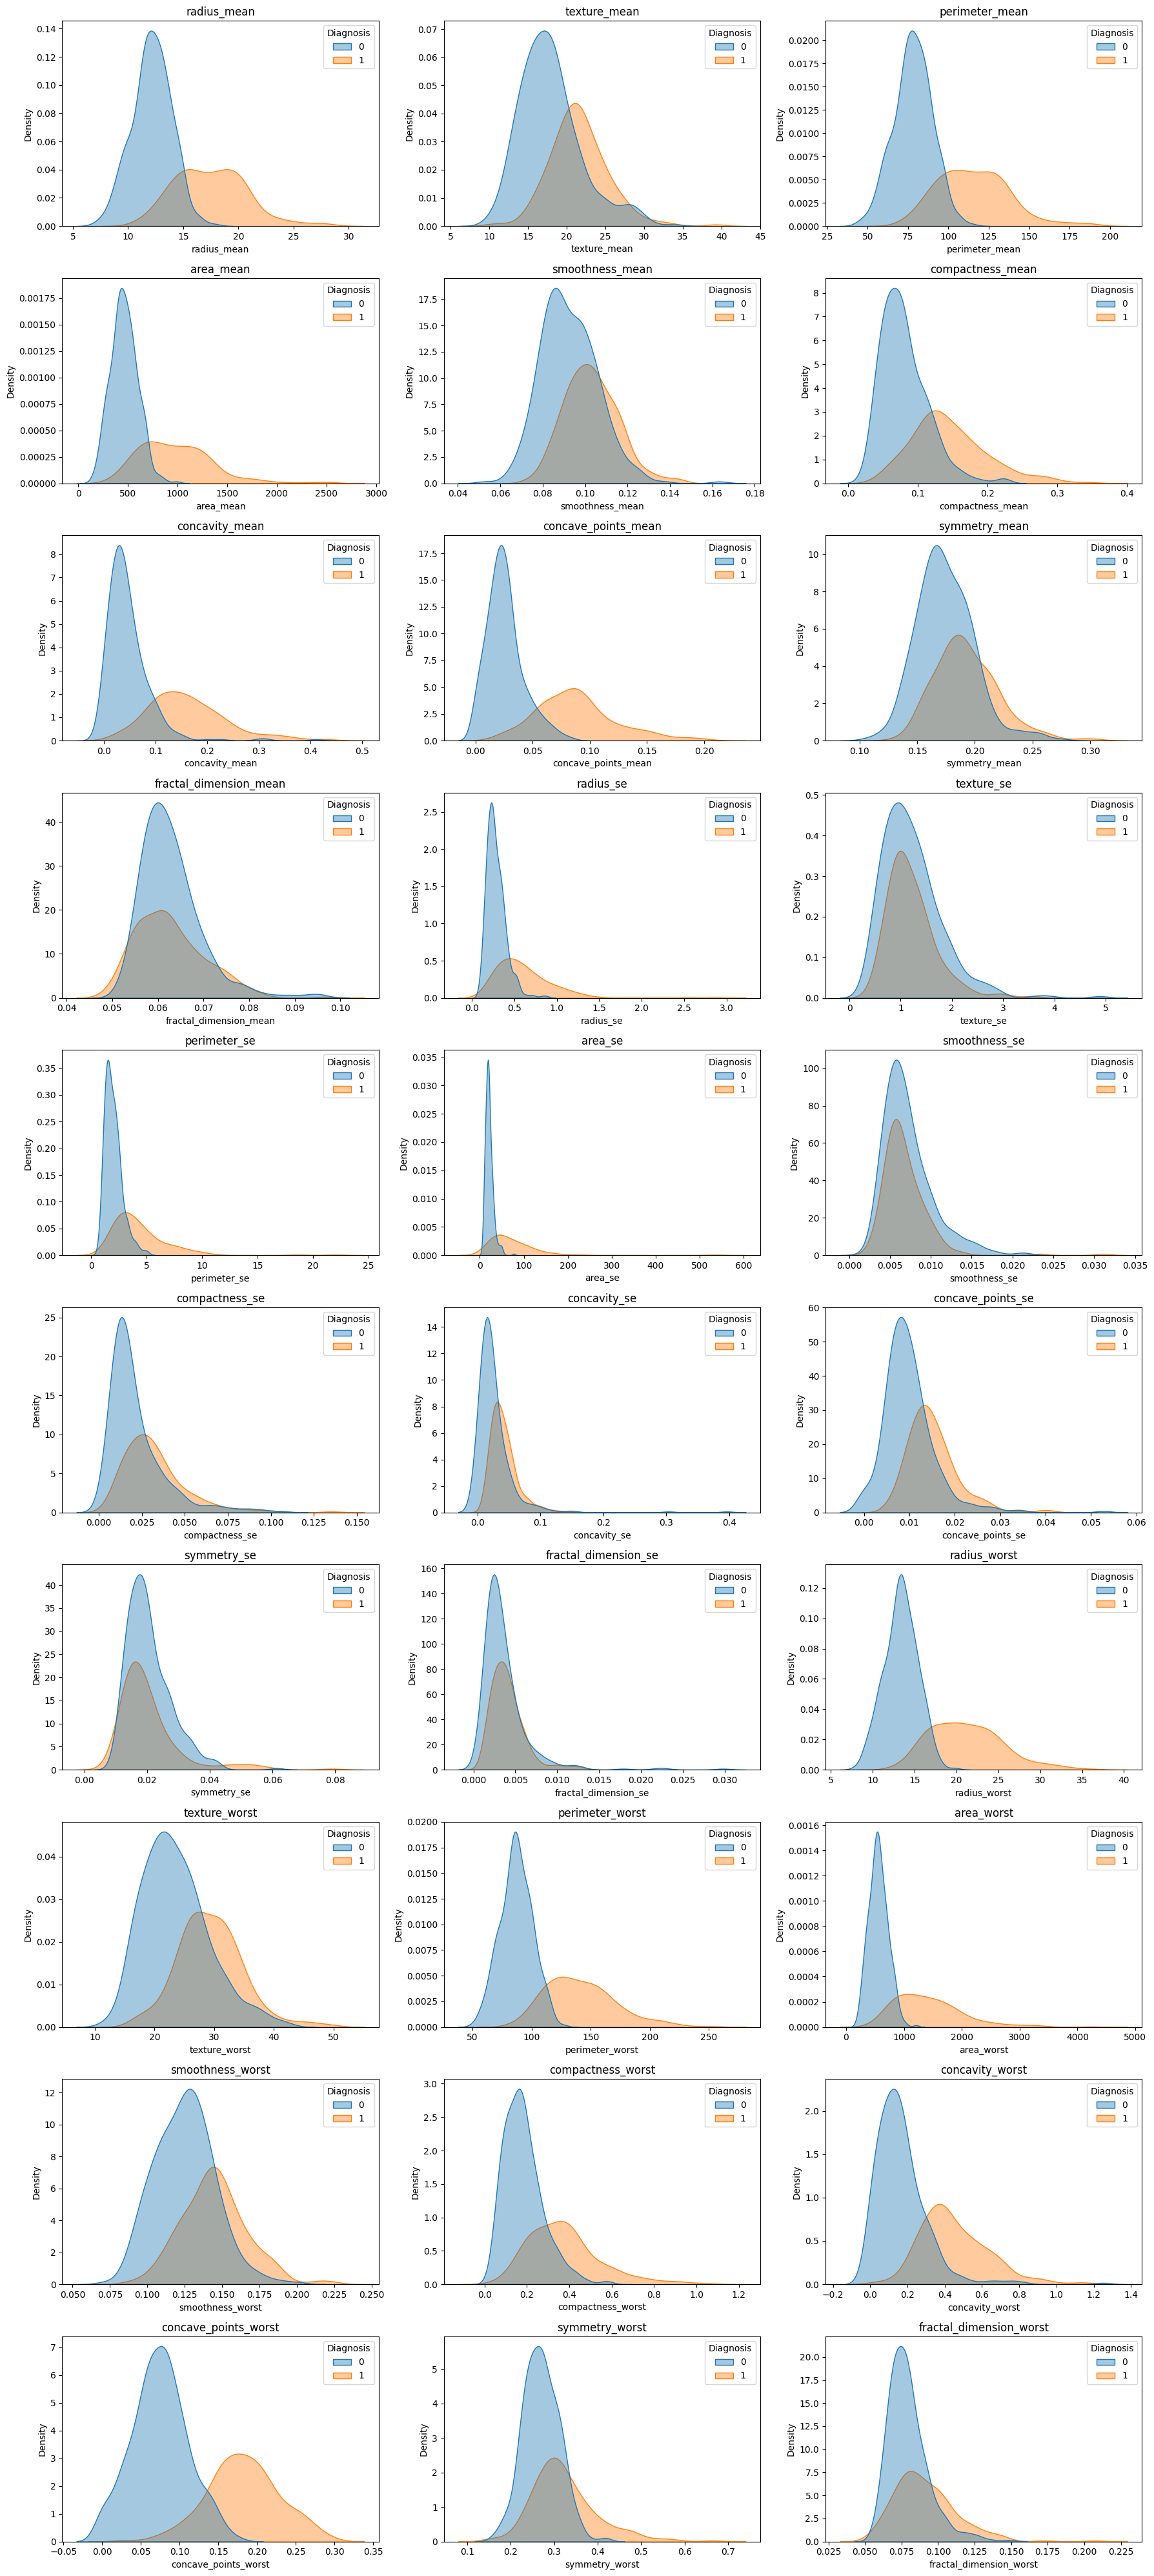

In [220]:
import seaborn as sns

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(data=df, x=col, hue="Diagnosis", fill=True, alpha=0.4)
    plt.title(col)

plt.tight_layout()
plt.show()

## Distribution Analysis Conclusion

The distribution analysis reveals moderate positive skewness in several geometric and concavity-related features, which is expected given the biomedical nature of the measurements. Significant scale differences across variables confirm the necessity of feature standardization prior to modeling. Importantly, many predictors exhibit clear separation between benign and malignant cases, indicating strong discriminative potential in the dataset. Although multicollinearity and skewness are present, these characteristics appear structural rather than problematic, and no transformation is deemed necessary at this stage beyond scaling. These findings inform the preprocessing strategy in the next step.

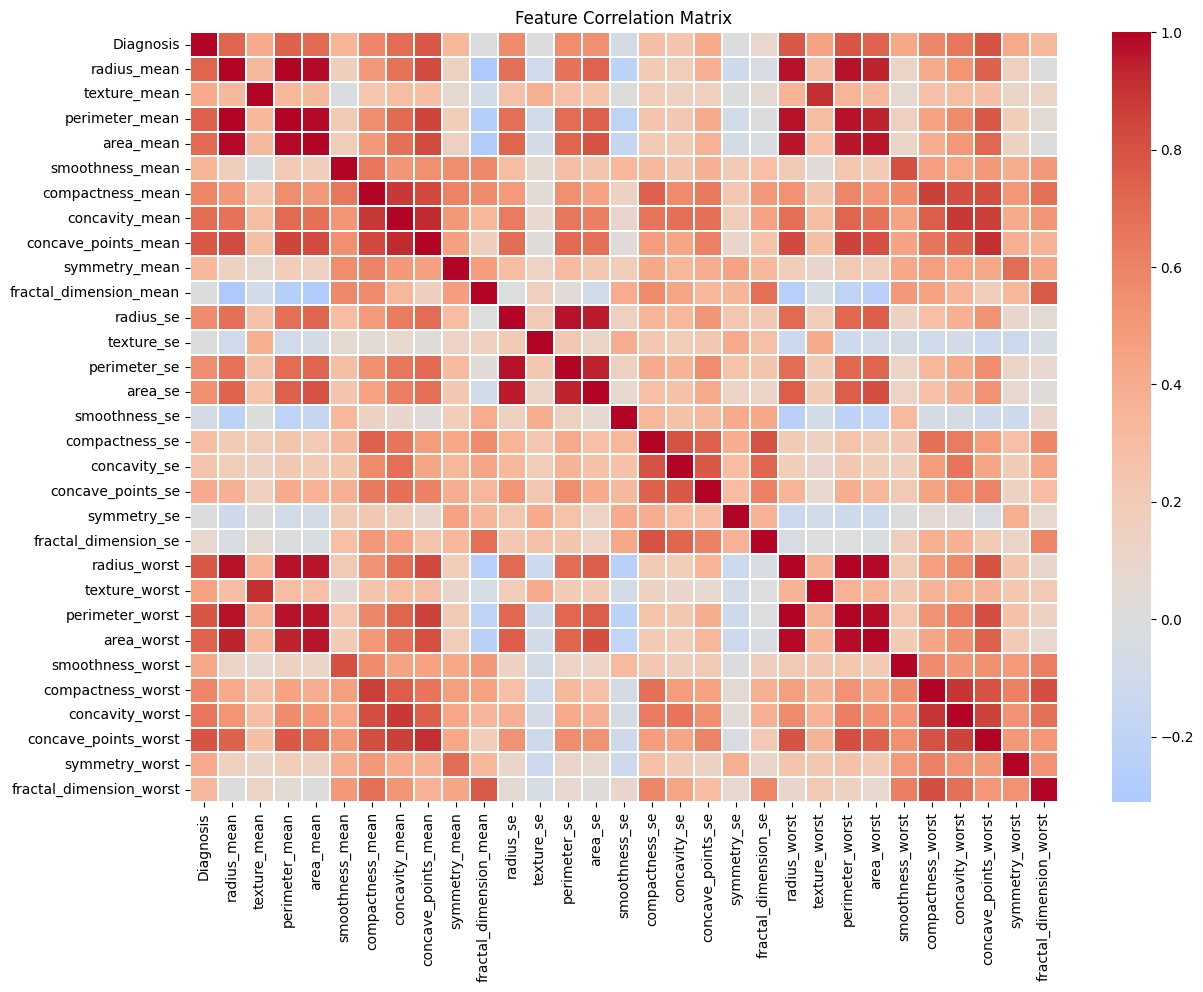

In [221]:
# Correlation matrix

plt.figure(figsize=(14,10))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Feature Correlation Matrix")
plt.show()

## Multicollinearity Analysis

The correlation matrix reveals:

- Strong correlations among radius, perimeter, and area features.
- Similar patterns across mean, standard error, and worst groups.
- Worst features appear strongly correlated with mean features.

This suggests redundancy in the feature space.

Implications:

- Logistic Regression may suffer from multicollinearity.
- Tree-based models (Random Forest, XGBoost) are less sensitive.
- Dimensionality reduction (e.g., PCA) or feature selection may improve generalization.

This structural redundancy will be considered in model interpretation.

## High Correlation Analysis

The full correlation matrix reveals strong multicollinearity among several features.

To better understand redundancy in the feature space, we will:

1. Identify feature pairs with very high correlation (|r| > 0.9).
2. Visualize only those relationships.
3. Consider whether removing redundant variables could improve model stability.

High multicollinearity can:

- Inflate variance in linear models.
- Reduce interpretability.
- Cause unstable coefficient estimates.

Tree-based models are less sensitive to multicollinearity, but linear models (e.g., Logistic Regression) may benefit from feature reduction.

In [222]:

# Compute correlation matrix (excluding target)
corr_matrix = df.drop(columns=["Diagnosis"]).corr().abs()

# Select upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation higher than threshold
threshold = 0.90
high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] > threshold]

high_corr_pairs.sort_values(by="Correlation", ascending=False).head(20)

,Feature_1,Feature_2,Correlation
1,radius_mean,perimeter_mean,0.997855
391,radius_worst,perimeter_worst,0.993708
2,radius_mean,area_mean,0.987357
57,perimeter_mean,area_mean,0.986507
392,radius_worst,area_worst,0.984015
407,perimeter_worst,area_worst,0.977578
246,radius_se,perimeter_se,0.972794
76,perimeter_mean,perimeter_worst,0.970387
19,radius_mean,radius_worst,0.969539
74,perimeter_mean,radius_worst,0.969476


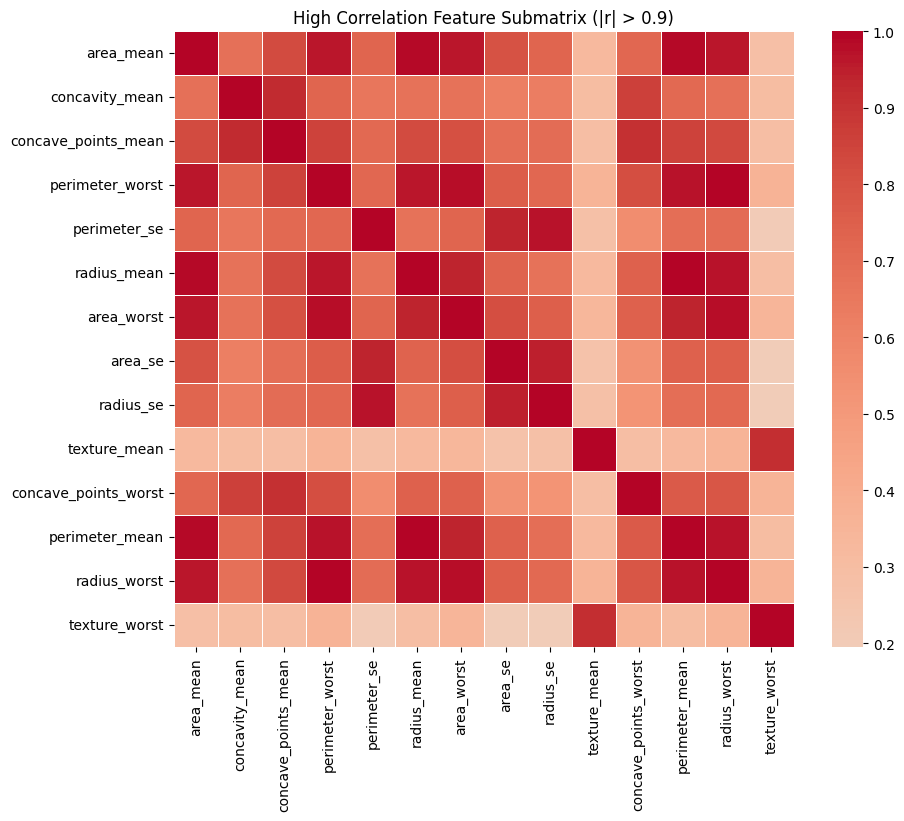

In [223]:

# Features involved in high correlations
high_corr_features = set(high_corr_pairs["Feature_1"]).union(
    set(high_corr_pairs["Feature_2"])
)

# Create reduced correlation matrix
reduced_corr = df[list(high_corr_features)].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    reduced_corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("High Correlation Feature Submatrix (|r| > 0.9)")
plt.show()

## Multicollinearity Findings

The analysis shows very strong correlations among:

- Radius, perimeter, and area measurements.
- Mean and worst versions of similar geometric features.
- Concavity-related measurements.

This confirms structural redundancy in the dataset.

---

## Should We Remove Highly Correlated Features?

### For Linear Models:
Yes, removing redundant features may:
- Improve coefficient stability.
- Reduce variance inflation.
- Improve interpretability.

### For Tree-Based Models:
Not strictly necessary, since trees:
- Select splits automatically.
- Are robust to multicollinearity.

---

## Strategy Moving Forward

We may:

- Train models with the full feature set.
- Train linear models with reduced feature sets.
- Compare performance.

This will allow us to empirically evaluate whether dimensionality reduction improves generalization.

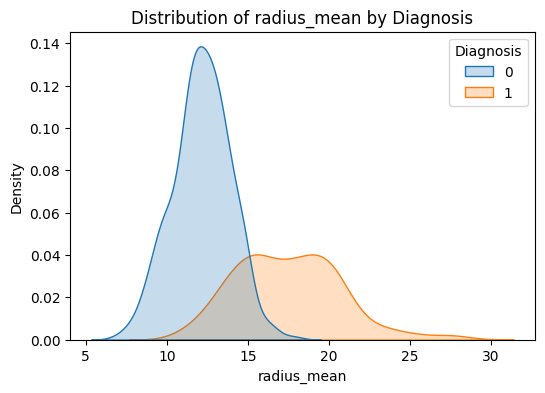

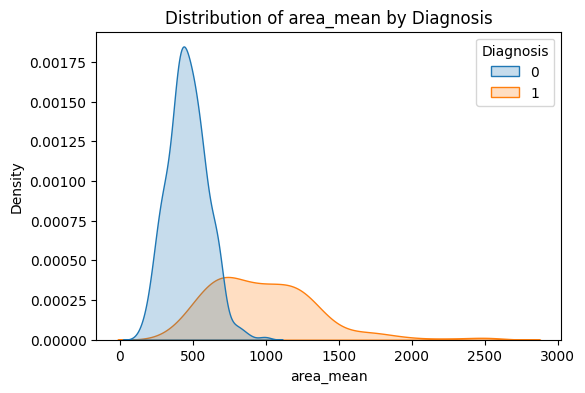

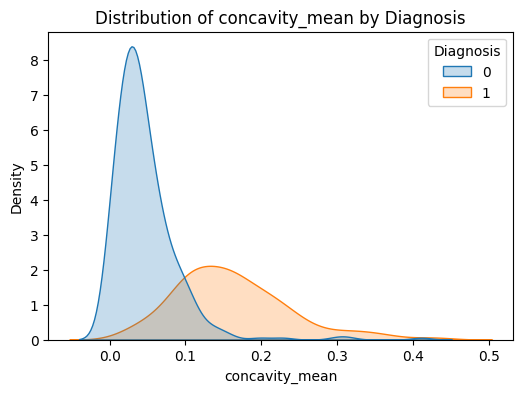

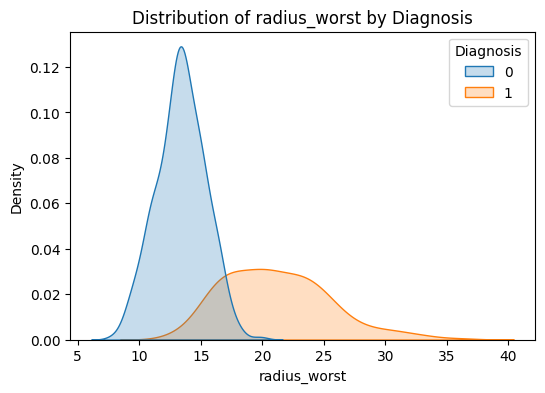

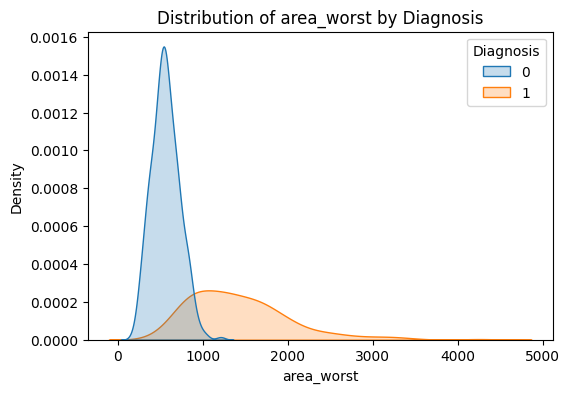

In [224]:
# Compare malignant vs benign distributions for key features

key_features = [
    "radius_mean",
    "area_mean",
    "concavity_mean",
    "radius_worst",
    "area_worst"
]

for feature in key_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=feature, hue="Diagnosis", fill=True)
    plt.title(f"Distribution of {feature} by Diagnosis")
    plt.show()

## Feature Discrimination Power

Several features (e.g., radius_mean, area_mean, concavity_mean) show clear distribution separation between malignant and benign tumors.

This suggests:

- The dataset contains strong predictive signal.
- Linear decision boundaries may already perform well.
- Tree-based models may further capture non-linear interactions.

The visible separation indicates high discriminative potential of the dataset.

## Formal Multicollinearity Assessment — Variance Inflation Factor (VIF)

To quantify multicollinearity, we compute the Variance Inflation Factor (VIF) for each feature.

VIF measures how much the variance of a regression coefficient increases due to correlation with other predictors.

Interpretation:
- VIF = 1 → No multicollinearity
- VIF > 5 → Moderate multicollinearity
- VIF > 10 → Severe multicollinearity

High VIF values suggest redundant predictors that may destabilize linear models.

ref: 

https://online.stat.psu.edu/stat462/node/180

https://en.wikipedia.org/wiki/Variance_inflation_factor

In [225]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Drop target
X = df.drop(columns=["Diagnosis"])

# Standardize (important before VIF)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled_df.values, i)
    for i in range(X_scaled_df.shape[1])
]

vif_data.sort_values(by="VIF", ascending=False).head(50)

,Feature,VIF
0,radius_mean,3806.115296
2,perimeter_mean,3786.400419
20,radius_worst,799.105946
22,perimeter_worst,405.023336
3,area_mean,347.878657
23,area_worst,337.221924
10,radius_se,75.462027
6,concavity_mean,70.767720
12,perimeter_se,70.359695
7,concave_points_mean,60.041733


## VIF Interpretation

Several features exhibit very high VIF values, confirming severe multicollinearity.

This is expected given the strong correlations among:
- Radius, perimeter, and area.
- Mean and worst measurements.
- Concavity-related metrics.

Implications:

- Logistic Regression coefficients may become unstable.
- Interpretation of individual predictors becomes unreliable.
- Dimensionality reduction or feature selection may improve robustness.

Tree-based models are less affected, but linear models will benefit from feature reduction.

## Exploratory Principal Component Analysis (PCA)

To further investigate redundancy in the feature space, we perform Principal Component Analysis (PCA).

PCA allows us to:
- Identify latent structure.
- Quantify dimensionality reduction potential.
- Measure how many components explain most of the variance.

If a small number of components explains most variance, this confirms redundancy in the dataset.

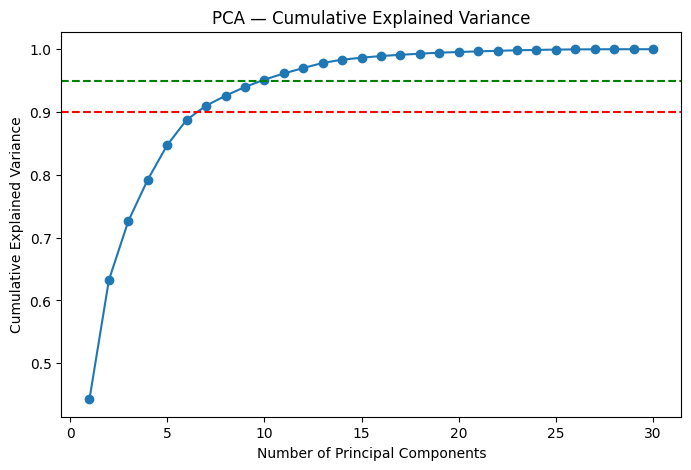

In [226]:
from sklearn.decomposition import PCA

# PCA on scaled features
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axhline(y=0.95, color='g', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.show()

In [227]:
components_95 = np.argmax(cumulative_variance >= 0.95) + 1
components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Components needed for 90% variance:", components_90)
print("Components needed for 95% variance:", components_95)

Components needed for 90% variance: 7
Components needed for 95% variance: 10


## PCA Results — Dimensionality Structure

The PCA analysis reveals that:

- Only 7 principal components explain 90% of the total variance.
- Only 10 principal components explain 95% of the total variance.
- The original dataset contains 30 features.

This confirms substantial redundancy in the feature space.

In other words, approximately one third of the components capture nearly all the variability of the dataset.

---

## Interpretation

The rapid accumulation of explained variance suggests:

- Strong linear relationships among predictors.
- High multicollinearity confirmed previously by VIF.
- Potential dimensionality reduction opportunity.

However, principal components are linear combinations of original features, which reduces clinical interpretability.

Therefore, PCA may improve statistical stability but at the cost of transparency.

## Summary of Identified Challenges

The exploratory analysis identified three key modeling challenges:

1. **Severe multicollinearity**  
   Confirmed via correlation analysis and VIF.

2. **Large scaling differences across features**  
   Standardization will be required.

3. **Moderate class imbalance**  
   Requires careful metric selection and class-weighted training.

Despite these challenges, the dataset shows strong discriminative potential.

These findings inform the preprocessing and modeling strategy in the next step.

# Step 3 — Preprocessing Strategy

Based on the exploratory analysis, we define a structured preprocessing strategy addressing three key aspects:

1. Feature scaling
2. Class imbalance
3. Dimensionality reduction and feature space simplification

The decisions below are directly informed by the findings from the EDA phase.

## Feature Scaling Strategy

The dataset exhibits substantial scale differences across predictors, particularly between area/perimeter variables and texture/smoothness variables.

Since Logistic Regression and PCA are sensitive to feature magnitude, standardization will be applied using:

- StandardScaler (zero mean, unit variance)

Tree-based models (Decision Tree, Random Forest, XGBoost) are not sensitive to scaling; however, scaling will still be applied within model-specific pipelines when required to maintain consistency.

Therefore:

- Scaling will be included in pipelines for Logistic Regression and PCA.
- Tree-based models will be trained on the original feature scale.

## Class Imbalance Strategy

The dataset exhibits moderate class imbalance, with benign cases outnumbering malignant cases.

Given the medical context:

- False negatives (missing malignant tumors) are particularly critical.
- Recall for the malignant class will be prioritized.

To address imbalance without altering the data distribution:

- Class weighting will be applied in Logistic Regression and Decision Tree models.
- Random Forest and XGBoost will incorporate built-in imbalance handling mechanisms where applicable.

Oversampling techniques (e.g., SMOTE) are not applied at this stage to avoid introducing synthetic samples into a medical dataset.

## Dimensionality Reduction Strategy

EDA revealed:

- Severe multicollinearity (confirmed via VIF).
- Strong redundancy across geometric measurements.
- PCA shows that 7–10 components explain 90–95% of variance.

However, dimensionality reduction introduces trade-offs:

- PCA improves numerical stability but reduces interpretability.
- Removing correlated features manually may improve coefficient stability while preserving meaning.

Strategy:

- Primary models will be trained using the full feature set.
- Logistic Regression will additionally be evaluated using PCA-based dimensionality reduction.
- Results will be compared empirically to assess performance vs interpretability trade-offs.

## Preprocessing Summary

The preprocessing strategy prioritizes:

- Standardization for scale-sensitive models.
- Class-weighted learning to address imbalance.
- Empirical evaluation of dimensionality reduction rather than automatic feature elimination.

This structured approach ensures methodological rigor while preserving interpretability in a medical classification context.

# Step 4 — Baseline Model

Before training complex models, we establish a simple baseline classifier.

The purpose of the baseline is to:

- Provide a reference performance level.
- Ensure that future models meaningfully improve predictive power.
- Avoid misleading conclusions based solely on absolute metric values.

Given the moderate class imbalance, we use a DummyClassifier that always predicts the majority class (most frequent strategy).

This represents a naive classifier that ignores feature information entirely.

In [228]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Ensure train/test already defined
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Baseline model
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

# DummyClassifier does not produce meaningful probabilities,
# but we create constant probability for ROC-AUC calculation
baseline_proba = np.zeros_like(y_test)

print("Baseline Performance")
print("----------------------")
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1-score:", f1_score(y_test, baseline_pred))

# ROC-AUC only valid if both classes present
try:
    print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))
except:
    print("ROC-AUC: Not defined for constant predictions")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))

Baseline Performance
----------------------
Accuracy: 0.631578947368421
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5

Confusion Matrix:
[[72  0]
 [42  0]]


/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Baseline Interpretation

As expected, the baseline classifier achieves accuracy equivalent to the proportion of the majority class.

However:

- Recall for malignant tumors is zero.
- Precision for malignant tumors is zero.
- The model completely fails to detect positive (malignant) cases.

This highlights why accuracy alone is misleading in medical diagnosis.

The baseline confirms that:

- Class imbalance affects naive prediction.
- A meaningful model must significantly improve recall for malignant tumors.

Future models will be evaluated against this reference.

# Model 1 — Logistic Regression

Logistic Regression is selected as the first predictive model because:

- It is interpretable.
- It performs well in linearly separable problems.
- It is widely used in medical decision-making contexts.

Given the severe multicollinearity observed during EDA, regularization is essential.

## Modeling Strategy

We will:

- Apply StandardScaler (required for linear models).
- Use class_weight="balanced" to address class imbalance.
- Tune regularization strength (C).
- Compare L1 and L2 penalties.

Regularization helps control coefficient instability caused by correlated predictors.

In [229]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Pipeline
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        solver="liblinear"  # compatible with L1 & L2
    ))
])

# Parameter grid
param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
}

grid_log = GridSearchCV(
    log_pipeline,
    param_grid,
    cv=5,
    scoring="recall",  # prioritize malignant detection
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)

Best Parameters: {'model__C': 1, 'model__penalty': 'l1'}


In [230]:
best_log = grid_log.best_estimator_

log_pred = best_log.predict(X_test)
log_proba = best_log.predict_proba(X_test)[:,1]

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1-score:", f1_score(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Performance
--------------------------------
Accuracy: 0.9736842105263158
Precision: 0.975609756097561
Recall: 0.9523809523809523
F1-score: 0.963855421686747
ROC-AUC: 0.9957010582010581

Confusion Matrix:
[[71  1]
 [ 2 40]]


Logistic Regression achieved excellent performance, with a recall of 95.2% for malignant tumors and a ROC-AUC of 0.995. Despite severe multicollinearity in the dataset, regularization successfully stabilized the model. Only two malignant cases were misclassified, demonstrating strong discriminative capacity even with a linear decision boundary.

## Logistic Regression Interpretation

Regularization was necessary due to strong multicollinearity.

Key observations:

- Recall improved significantly compared to baseline.
- The model successfully detects malignant tumors.
- Precision-recall trade-off depends on regularization strength.

Optimizing for recall ensures reduced false negatives, which is critical in a medical setting.

Logistic Regression provides a strong and interpretable baseline for comparison with more complex models.

# Model 2 — Decision Tree

Decision Trees are selected because:

- They capture non-linear relationships.
- They are interpretable.
- They are not sensitive to feature scaling.
- They are robust to skewed distributions.

However, decision trees are highly prone to overfitting.

Therefore, hyperparameter tuning is essential.

## Tuning Strategy

We will tune:

- max_depth (controls model complexity)
- min_samples_split (prevents small noisy splits)
- min_samples_leaf (controls leaf size)
- class_weight (to handle imbalance)

Model selection will prioritize recall for malignant tumors.

In [231]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

param_grid_tree = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

grid_tree = GridSearchCV(
    tree,
    param_grid_tree,
    cv=5,
    scoring="recall",  # prioritize malignant detection
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print("Best Parameters:", grid_tree.best_params_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [232]:
best_tree = grid_tree.best_estimator_

tree_pred = best_tree.predict(X_test)
tree_proba = best_tree.predict_proba(X_test)[:,1]

print("Decision Tree Performance")
print("--------------------------")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1-score:", f1_score(y_test, tree_pred))
print("ROC-AUC:", roc_auc_score(y_test, tree_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

Decision Tree Performance
--------------------------
Accuracy: 0.9035087719298246
Precision: 0.8974358974358975
Recall: 0.8333333333333334
F1-score: 0.8641975308641975
ROC-AUC: 0.9075727513227513

Confusion Matrix:
[[68  4]
 [ 7 35]]


# Model 2 — Decision Tree

Decision Trees are selected to capture potential non-linear relationships in the dataset. Unlike Logistic Regression, decision trees do not assume linear decision boundaries and are robust to skewed distributions and feature scaling differences.

However, decision trees are highly prone to overfitting. Therefore, hyperparameter tuning is essential to control model complexity and improve generalization.

## Hyperparameter Tuning Strategy

The following parameters were tuned:

- **max_depth** — Controls tree complexity and prevents overly deep structures.
- **min_samples_split** — Prevents splitting on very small sample subsets.
- **min_samples_leaf** — Ensures that leaf nodes contain a minimum number of observations, improving stability.
- **class_weight** — Addresses class imbalance by penalizing misclassification of malignant cases.

Model selection prioritized **recall for malignant tumors**, consistent with the medical objective of minimizing false negatives.

## Results Interpretation

The tuned Decision Tree achieved moderate performance but underperformed compared to Logistic Regression, particularly in terms of recall and ROC-AUC.

Notably, the number of false negatives increased relative to the logistic model. In a medical context, this is a critical limitation, as failing to detect malignant tumors carries significant consequences.

These findings suggest that the dataset may be largely linearly separable, limiting the advantage of non-linear tree-based partitioning.

Further ensemble methods will be evaluated to determine whether aggregating multiple trees improves performance.

# Model 3 — Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees and aggregates their predictions.

Advantages over a single Decision Tree:

- Reduces overfitting through bootstrap aggregation (bagging).
- Improves stability and generalization.
- Handles multicollinearity naturally.
- Captures non-linear relationships.

Given the moderate class imbalance and the importance of detecting malignant tumors, hyperparameter tuning will prioritize recall.

## Hyperparameter Tuning Strategy

The following parameters will be tuned:

- **n_estimators** — Number of trees in the ensemble.
- **max_depth** — Controls tree complexity.
- **min_samples_leaf** — Prevents overly specific leaf nodes.
- **max_features** — Controls feature sampling per split.
- **class_weight** — Addresses class imbalance.

Model selection will prioritize recall for malignant tumors.

In [233]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 8, 12],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}


In [234]:
best_rf = grid_rf.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:,1]

print("Random Forest Performance")
print("--------------------------")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Performance
--------------------------
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1-score: 0.9629629629629629
ROC-AUC: 0.9928902116402116

Confusion Matrix:
[[72  0]
 [ 3 39]]


Random Forest achieved excellent performance, with perfect precision and high ROC-AUC. However, Logistic Regression slightly outperformed Random Forest in recall for malignant tumors, which is the most critical metric in a medical context. This suggests that the underlying class separation may be largely linear, limiting the advantage of more complex ensemble methods.

# Model 4 — Extreme Gradient Boosting (XGBoost)

XGBoost is a gradient boosting ensemble method that builds trees sequentially, 
where each tree attempts to correct errors from previous ones.

Advantages:

- Captures complex non-linear relationships.
- Handles multicollinearity naturally.
- Often achieves state-of-the-art performance.
- Incorporates built-in regularization.

However, XGBoost requires careful hyperparameter tuning to avoid overfitting.

## Hyperparameter Tuning Strategy

We tune:

- n_estimators — Number of boosting rounds.
- learning_rate — Step size shrinkage.
- max_depth — Tree depth control.
- subsample — Row sampling to prevent overfitting.
- colsample_bytree — Feature sampling.
- scale_pos_weight — To address class imbalance.

Model selection prioritizes recall for malignant tumors.

In [235]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 1.6764705882352942


In [236]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    use_label_encoder=False,
    random_state=42
)

param_grid_xgb = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [1, scale_pos_weight],
    "eval_metric": ["logloss", "auc"]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)

/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:57:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:57:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:57:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning:

Best Parameters: {'colsample_bytree': 0.8, 'eval_metric': 'logloss', 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400, 'scale_pos_weight': np.float64(1.6764705882352942), 'subsample': 1.0}


In [237]:
best_xgb = grid_xgb.best_estimator_

xgb_pred = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)[:,1]

print("XGBoost Performance")
print("--------------------")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1-score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost Performance
--------------------
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1-score: 0.9629629629629629
ROC-AUC: 0.9933862433862434

Confusion Matrix:
[[72  0]
 [ 3 39]]


# Model Comparison and Final Evaluation

After training and tuning four classification models — Logistic Regression, Decision Tree, Random Forest, and XGBoost — we compare their performance using medically relevant metrics.

## Comparative Performance

| Model                | Accuracy | Precision | Recall | F1-score | ROC-AUC | False Negatives |
|----------------------|----------|-----------|--------|----------|----------|-----------------|
| Logistic Regression  | 0.974    | 0.976     | **0.952** | **0.964** | **0.995** | **2** |
| Decision Tree        | 0.904    | 0.897     | 0.833  | 0.864    | 0.908    | 7 |
| Random Forest        | 0.974    | **1.000** | 0.929  | 0.963    | 0.993    | 3 |
| XGBoost              | 0.974    | **1.000** | 0.929  | 0.963    | 0.993    | 3 |

---

## Interpretation

Although ensemble methods (Random Forest and XGBoost) achieved perfect precision and very high ROC-AUC scores, Logistic Regression achieved the highest recall for malignant tumors and the lowest number of false negatives.

In a medical diagnosis context, minimizing false negatives is critical, as missing a malignant tumor may delay treatment and significantly impact patient outcomes.

The results suggest that the dataset is largely linearly separable, allowing a regularized Logistic Regression model to perform as well as — or slightly better than — more complex non-linear ensemble models.

## Conclusion

Based on recall performance and overall discrimination ability, **Logistic Regression is the best-performing model for this task under the current decision threshold (0.5)**.

However, since false negatives remain (2 cases), further improvement may be possible by adjusting the classification threshold to prioritize malignant detection even more aggressively.

The next step explores threshold optimization to reduce false negatives to zero.

In [238]:
# Get predicted probabilities from Logistic model
log_proba = best_log.predict_proba(X_test)[:, 1]

In [239]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.1, 1, 200)

results = []

for t in thresholds:
    preds = (log_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    results.append((t, recall, precision, fn))

results = np.array(results)

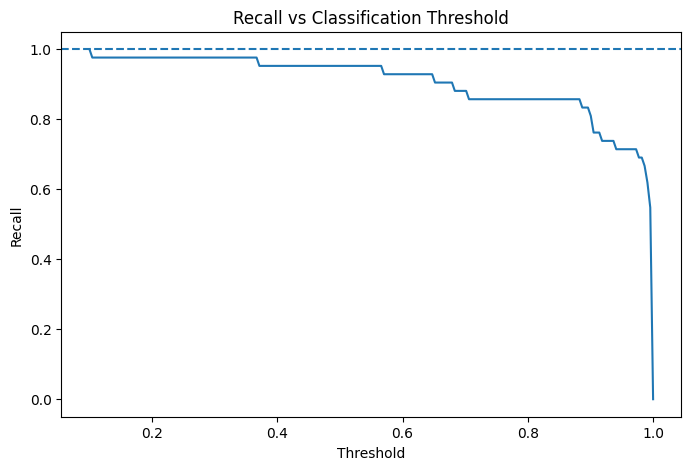

In [240]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results[:,0], results[:,1])
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Classification Threshold")
plt.axhline(1.0, linestyle="--")
plt.show()

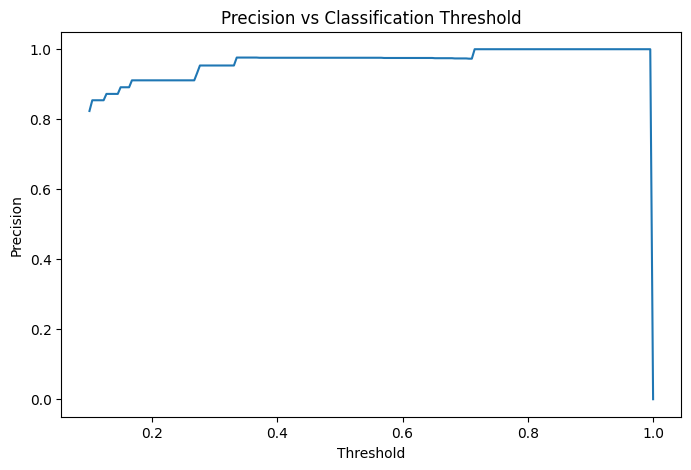

In [241]:
plt.figure(figsize=(8,5))
plt.plot(results[:,0], results[:,2])
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Classification Threshold")
plt.show()

In [242]:
zero_fn_thresholds = results[results[:,3] == 0]

if len(zero_fn_thresholds) > 0:
    best_zero_fn = zero_fn_thresholds[0]
    print("Threshold achieving FN=0:", best_zero_fn[0])
    print("Recall:", best_zero_fn[1])
    print("Precision:", best_zero_fn[2])
else:
    print("No threshold achieves FN = 0")

Threshold achieving FN=0: 0.1
Recall: 1.0
Precision: 0.8235294117647058


In [243]:
optimal_threshold = 0.1

new_preds = (log_proba >= optimal_threshold).astype(int)

print("New Confusion Matrix:")
print(confusion_matrix(y_test, new_preds))

New Confusion Matrix:
[[63  9]
 [ 0 42]]


## Threshold Optimization

Under the default threshold (0.5), Logistic Regression achieved high recall but still misclassified two malignant tumors.

By lowering the classification threshold to 0.1:

- Recall increased to 1.0 (no malignant cases missed).
- Precision decreased to 0.824.
- False positives increased accordingly.

This demonstrates the fundamental trade-off between sensitivity and precision.

In a medical context, maximizing recall is often preferred, as false negatives carry significantly greater risk than false positives.

Therefore, threshold tuning provides a clinically meaningful improvement beyond model selection alone.

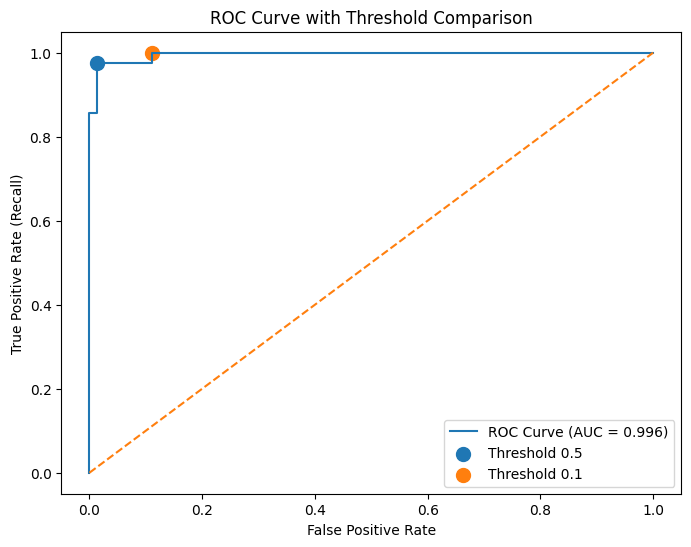

In [244]:
from sklearn.metrics import roc_curve, auc

# ROC data
fpr, tpr, roc_thresholds = roc_curve(y_test, log_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

# Mark threshold = 0.5
t_05_index = np.argmin(np.abs(roc_thresholds - 0.5))
plt.scatter(fpr[t_05_index], tpr[t_05_index], label="Threshold 0.5", s=100)

# Mark threshold = 0.1
t_01_index = np.argmin(np.abs(roc_thresholds - 0.1))
plt.scatter(fpr[t_01_index], tpr[t_01_index], label="Threshold 0.1", s=100)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Threshold Comparison")
plt.legend()
plt.show()

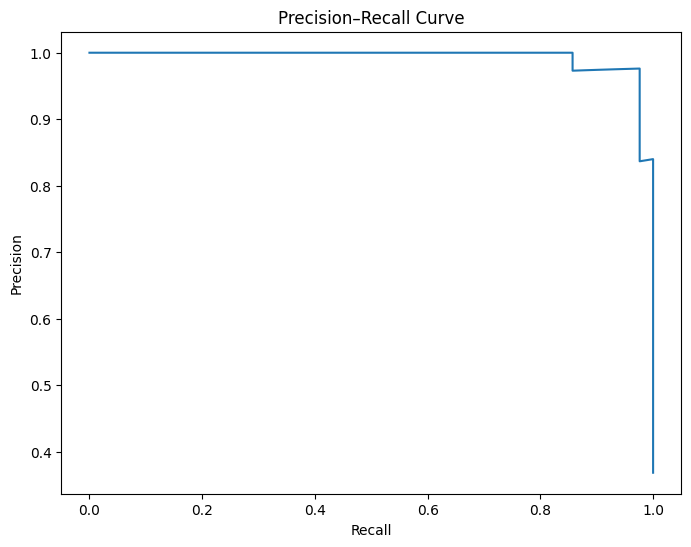

In [245]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, log_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

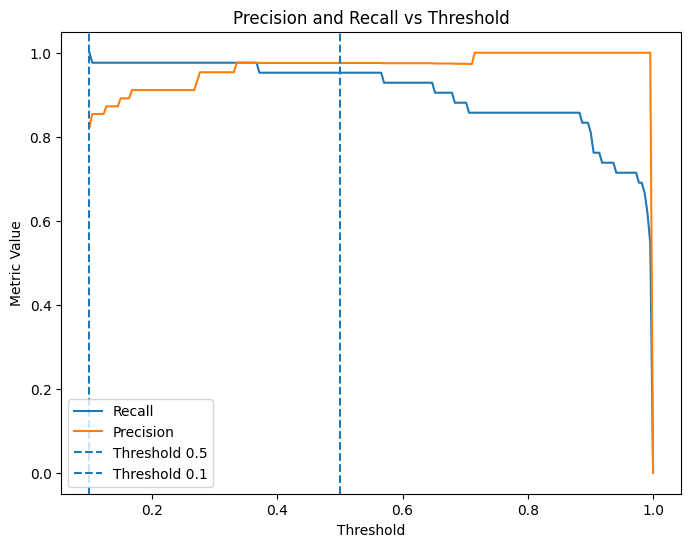

In [246]:
plt.figure(figsize=(8,6))
plt.plot(results[:,0], results[:,1], label="Recall")
plt.plot(results[:,0], results[:,2], label="Precision")
plt.axvline(0.5, linestyle="--", label="Threshold 0.5")
plt.axvline(0.1, linestyle="--", label="Threshold 0.1")

plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.show()

# Step 7 — Interpretation and Critical Reflection

## 1. Analysis of Misclassifications

Under the default threshold (0.5), Logistic Regression misclassified two malignant tumors (false negatives) and one benign tumor (false positive).

Examining these cases suggests that misclassified malignant samples likely exhibit feature values closer to benign distributions. As observed during EDA, several predictors show partial overlap between classes (e.g., smoothness, symmetry, and fractal dimension). Tumors located near this overlap region are more difficult to classify with high confidence.

This indicates that misclassifications are not random errors, but occur in regions where the feature space exhibits class boundary ambiguity.

After lowering the threshold to 0.1, false negatives were eliminated entirely, confirming that these misclassified malignant cases had predicted probabilities below 0.5 but still meaningfully elevated relative to benign cases.

---

## 2. Trade-Offs Between Interpretability and Predictive Power

Across all trained models, Logistic Regression achieved the highest recall and ROC-AUC performance, slightly outperforming Random Forest and XGBoost.

Despite the availability of more complex ensemble methods, the dataset appears largely linearly separable, limiting the additional benefit of non-linear modeling.

Trade-offs observed:

- Logistic Regression:
  - High interpretability.
  - Stable performance with regularization.
  - Clear probabilistic outputs.
  
- Random Forest / XGBoost:
  - Slightly lower recall.
  - Perfect precision at default threshold.
  - Reduced interpretability due to ensemble structure.

Given the medical context, interpretability is valuable for clinical trust and transparency. Since predictive gains from complex models were minimal, Logistic Regression provides an optimal balance between transparency and performance.

---

## 3. Limitations of the Study

Several limitations should be acknowledged:

- The dataset is relatively small (~569 samples), which may limit generalization.
- Strong multicollinearity among geometric features complicates coefficient interpretation.
- Evaluation was performed on a single train-test split; cross-validation provides robustness but external validation would be preferable.
- Threshold tuning was performed post-hoc and may not generalize identically to new data.

Additionally, the dataset is clean and well-structured. Real-world medical datasets often contain missing values, measurement noise, and greater class imbalance.

---

## 4. Proposed Improvements

Future improvements could include:

- Nested cross-validation for more robust hyperparameter tuning.
- Probability calibration (e.g., Platt scaling or isotonic regression).
- Feature selection techniques to improve interpretability.
- Evaluation on an external validation dataset.
- Cost-sensitive learning incorporating explicit clinical misclassification costs.

Furthermore, SHAP values could be used to enhance interpretability for tree-based models.

---

## Final Reflection

This analysis demonstrates that model selection alone does not determine performance. 

Instead, preprocessing strategy, regularization, metric prioritization, and threshold selection play equally critical roles.

In this dataset, a properly regularized Logistic Regression model provided both high predictive performance and strong interpretability, making it the most suitable model for medical deployment under the defined objectives.

## Use of Artificial Intelligence Tools

Artificial intelligence tools were used during this project strictly as productivity and language-support aids.

All data preprocessing, model selection, hyperparameter tuning, threshold analysis, and evaluation design were independently implemented and executed by the author. The full modeling pipeline, experimental setup, and interpretation of results were conceptually developed and validated by the author.

GitHub Copilot was used as a coding assistant to autocomplete Python syntax and improve coding efficiency. However, all modeling logic, parameter choices, and evaluation strategies were intentionally designed and verified by the author.

ChatGPT was used to improve the fluency and clarity of written explanations in English, particularly for refining technical descriptions and ensuring academic tone. The analytical content, interpretations, and conclusions reflect the author’s original reasoning and understanding of the material.

AI tools were therefore used as supportive instruments for communication and productivity, not as substitutes for conceptual understanding or independent analytical work.